# Synthetic Raster-to-Vector Notebook: Adaptive Line Reconstruction

This notebook implements an improved classical vectorisation pipeline for simple black 1 px lines on a white 128×128 raster image.

The pipeline is:

1. Generate synthetic training/test-style examples with up to 5 random vector lines.
2. Rasterise vectors into 128×128 black-on-white images.
3. Convert dark pixels into a binary dot cloud using a 50% black threshold.
4. Detect connected components.
5. Detect intersections and endpoints using pixel neighbourhood degree.
6. Trace graph branches between endpoints/intersections.
7. Fit line vectors to traced pixel branches using least squares.
8. Merge approximately collinear segments.
9. Rasterise predicted vectors back to an image.
10. Display 10 random examples showing input, predicted vectors, and rasterised output.

This is not a neural network. It is an interpretable geometric baseline that can be compared against machine learning models.


In [1]:
# Optional: install missing packages if needed
# Run this cell only if imports fail.
# !pip install numpy matplotlib pillow tqdm


In [2]:
import math
import random
from dataclasses import dataclass
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


In [3]:
# -----------------------------
# Configuration
# -----------------------------
IMG_SIZE = 128
MAX_LINES = 5
LINE_WIDTH = 1
N_SAMPLES = 200
SEED = 42

BLACK = 0
WHITE = 255
THRESHOLD_BLACKNESS = 0.50

random.seed(SEED)
np.random.seed(SEED)


## 1. Synthetic vector generation

Each sample contains between 1 and 5 random straight-line vectors. The lines are rasterised as 1 px black strokes on a white 128×128 image.


In [4]:
@dataclass
class VectorLine:
    x1: float
    y1: float
    x2: float
    y2: float

    def as_tuple(self):
        return (self.x1, self.y1, self.x2, self.y2)


def random_line(img_size=128, min_length=8):
    while True:
        x1 = random.randint(2, img_size - 3)
        y1 = random.randint(2, img_size - 3)
        x2 = random.randint(2, img_size - 3)
        y2 = random.randint(2, img_size - 3)
        length = math.hypot(x2 - x1, y2 - y1)
        if length >= min_length:
            return VectorLine(x1, y1, x2, y2)


def generate_vector_sample(max_lines=5, img_size=128):
    n_lines = random.randint(1, max_lines)
    return [random_line(img_size=img_size) for _ in range(n_lines)]


def rasterise_vectors(lines, img_size=128, line_width=1):
    image = Image.new('L', (img_size, img_size), WHITE)
    draw = ImageDraw.Draw(image)
    for line in lines:
        draw.line((line.x1, line.y1, line.x2, line.y2), fill=BLACK, width=line_width)
    return np.array(image, dtype=np.uint8)


def make_dataset(n_samples=200):
    vectors = []
    rasters = []
    for _ in range(n_samples):
        lines = generate_vector_sample(MAX_LINES, IMG_SIZE)
        raster = rasterise_vectors(lines, IMG_SIZE, LINE_WIDTH)
        vectors.append(lines)
        rasters.append(raster)
    return vectors, np.stack(rasters)

true_vectors, raster_images = make_dataset(N_SAMPLES)
print(raster_images.shape)


(200, 128, 128)


## 2. Pixel thresholding

The rule is:

- if a pixel is at least 50% black, assign it as a dot;
- otherwise ignore it.

For 8-bit grayscale, blackness is calculated as:

```python
blackness = 1 - pixel_value / 255
```


In [5]:
def threshold_to_dots(raster, blackness_threshold=0.50):
    blackness = 1.0 - raster.astype(np.float32) / 255.0
    binary = blackness >= blackness_threshold
    return binary


def dot_coordinates(binary):
    ys, xs = np.where(binary)
    return list(zip(xs.tolist(), ys.tolist()))

binary_example = threshold_to_dots(raster_images[0])
print('Number of black/dot pixels:', binary_example.sum())


Number of black/dot pixels: 64


## 3. Connected components

This groups neighbouring black pixels. For line drawings, one connected component may contain multiple crossing lines, so connected components alone are not enough. We still use them to restrict tracing to local pixel regions.


In [6]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def in_bounds(x, y, img_size=128):
    return 0 <= x < img_size and 0 <= y < img_size


def get_binary_neighbours(binary, x, y):
    h, w = binary.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        nx, ny = x + dx, y + dy
        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx]:
            out.append((nx, ny))
    return out


def connected_components(binary):
    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    components = []

    for y in range(h):
        for x in range(w):
            if not binary[y, x] or visited[y, x]:
                continue

            q = deque([(x, y)])
            visited[y, x] = True
            comp = []

            while q:
                px, py = q.popleft()
                comp.append((px, py))
                for nx, ny in get_binary_neighbours(binary, px, py):
                    if not visited[ny, nx]:
                        visited[ny, nx] = True
                        q.append((nx, ny))

            components.append(comp)

    return components

components = connected_components(binary_example)
print('Connected components:', len(components))
print('Component sizes:', [len(c) for c in components[:10]])


Connected components: 1
Component sizes: [64]


## 4. Endpoints and intersections

A line pixel can be treated as a graph node.

- degree 1 usually means endpoint;
- degree 2 usually means normal line continuation;
- degree 3 or more usually means an intersection or junction.

Because diagonal raster lines can create small neighbourhood artefacts, the code also compresses nearby junction pixels into one junction cluster.


In [7]:
def pixel_degree(binary, x, y):
    return len(get_binary_neighbours(binary, x, y))


def classify_graph_pixels(binary):
    endpoints = set()
    junctions = set()
    normal = set()

    ys, xs = np.where(binary)
    for x, y in zip(xs, ys):
        deg = pixel_degree(binary, x, y)
        if deg <= 1:
            endpoints.add((x, y))
        elif deg >= 3:
            junctions.add((x, y))
        else:
            normal.add((x, y))
    return endpoints, junctions, normal


def cluster_special_pixels(points, max_dist=1.5):
    points = set(points)
    clusters = []
    while points:
        start = points.pop()
        q = deque([start])
        cluster = [start]
        while q:
            px, py = q.popleft()
            nearby = []
            for p in points:
                if math.hypot(p[0] - px, p[1] - py) <= max_dist:
                    nearby.append(p)
            for p in nearby:
                points.remove(p)
                q.append(p)
                cluster.append(p)
        clusters.append(cluster)
    return clusters


def cluster_centres(clusters):
    centres = []
    for cluster in clusters:
        xs = [p[0] for p in cluster]
        ys = [p[1] for p in cluster]
        centres.append((float(np.mean(xs)), float(np.mean(ys))))
    return centres

endpoints, junctions, normal = classify_graph_pixels(binary_example)
print('Endpoints:', len(endpoints), 'Junction pixels:', len(junctions), 'Normal:', len(normal))
print('Junction clusters:', len(cluster_special_pixels(junctions)))


Endpoints: 2 Junction pixels: 0 Normal: 62
Junction clusters: 0


## 5. Branch tracing

Branches are traced from endpoints and junctions until another endpoint/junction is reached. This is what causes crossing/intersecting lines to break into separate vector segments.


In [8]:
def trace_branches(binary):
    endpoints, junctions, normal = classify_graph_pixels(binary)
    special = endpoints | junctions
    pixels = set(dot_coordinates(binary))

    visited_edges = set()
    branches = []

    def edge_key(a, b):
        return tuple(sorted([a, b]))

    # Trace from every special pixel outward.
    for start in list(special):
        for nxt in get_binary_neighbours(binary, *start):
            ek = edge_key(start, nxt)
            if ek in visited_edges:
                continue

            path = [start, nxt]
            visited_edges.add(ek)
            prev = start
            cur = nxt

            while cur not in special:
                neigh = get_binary_neighbours(binary, *cur)
                candidates = [p for p in neigh if p != prev]
                if not candidates:
                    break

                # Prefer unvisited edge. This prevents immediate loops.
                unvisited = [p for p in candidates if edge_key(cur, p) not in visited_edges]
                if not unvisited:
                    break

                # Continue in the smoothest direction.
                vx, vy = cur[0] - prev[0], cur[1] - prev[1]
                def turn_score(p):
                    wx, wy = p[0] - cur[0], p[1] - cur[1]
                    return -(vx * wx + vy * wy)

                nxt2 = min(unvisited, key=turn_score)
                visited_edges.add(edge_key(cur, nxt2))
                path.append(nxt2)
                prev, cur = cur, nxt2

            if len(path) >= 2:
                branches.append(path)

    # If there are loops with no special pixels, trace remaining edges.
    for p in pixels:
        for q in get_binary_neighbours(binary, *p):
            if edge_key(p, q) in visited_edges:
                continue
            path = [p, q]
            visited_edges.add(edge_key(p, q))
            branches.append(path)

    return branches, endpoints, junctions

branches, endpoints, junctions = trace_branches(binary_example)
print('Traced branches:', len(branches))
print('Branch lengths:', [len(b) for b in branches[:10]])


Traced branches: 1
Branch lengths: [64]


## 6. Line fitting

Each traced branch is fitted with a straight vector using principal component analysis. This gives an average best-fit line through the branch pixels.

For simple straight-line drawings, this works well. For curves, you would recursively split the branch until the line fit error is small enough.


In [9]:
def fit_line_pca(points):
    arr = np.array(points, dtype=np.float32)
    if len(arr) == 1:
        x, y = arr[0]
        return VectorLine(x, y, x, y), 0.0

    mean = arr.mean(axis=0)
    centered = arr - mean
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]

    projections = centered @ direction
    p1 = mean + projections.min() * direction
    p2 = mean + projections.max() * direction

    # perpendicular fit error
    reconstructed = np.outer(projections, direction) + mean
    errors = np.linalg.norm(arr - reconstructed, axis=1)
    mean_error = float(errors.mean())

    return VectorLine(p1[0], p1[1], p2[0], p2[1]), mean_error


def branch_to_vectors(branches, min_branch_pixels=3, max_fit_error=1.5):
    fitted = []
    for branch in branches:
        if len(branch) < min_branch_pixels:
            continue
        line, err = fit_line_pca(branch)
        if err <= max_fit_error:
            fitted.append((line, err, branch))
    return fitted

fitted = branch_to_vectors(branches)
print('Fitted vectors:', len(fitted))
for line, err, branch in fitted[:5]:
    print(line, 'error=', round(err, 3), 'pixels=', len(branch))


Fitted vectors: 1
VectorLine(x1=np.float32(36.811142), y1=np.float32(32.905487), x2=np.float32(5.188856), y2=np.float32(96.09451)) error= 0.223 pixels= 64


## 7. Merge approximately collinear vectors

Branch tracing may split a single original line into several small segments. This is useful at intersections, but sometimes it over-splits. The merge step joins nearby, approximately collinear segments while keeping junction breaks.


In [10]:
def line_angle(line):
    return math.atan2(line.y2 - line.y1, line.x2 - line.x1)


def angle_difference(a, b):
    diff = abs(a - b) % math.pi
    return min(diff, math.pi - diff)


def point_line_distance(px, py, line):
    x1, y1, x2, y2 = line.as_tuple()
    dx, dy = x2 - x1, y2 - y1
    denom = math.hypot(dx, dy)
    if denom == 0:
        return math.hypot(px - x1, py - y1)
    return abs(dy * px - dx * py + x2 * y1 - y2 * x1) / denom


def endpoints_close(a, b, threshold=3.0):
    ea = [(a.x1, a.y1), (a.x2, a.y2)]
    eb = [(b.x1, b.y1), (b.x2, b.y2)]
    return min(math.hypot(xa - xb, ya - yb) for xa, ya in ea for xb, yb in eb) <= threshold


def merge_two_lines(a, b):
    pts = [(a.x1, a.y1), (a.x2, a.y2), (b.x1, b.y1), (b.x2, b.y2)]
    merged, _ = fit_line_pca(pts)
    return merged


def merge_collinear_lines(lines, angle_thresh_deg=8, distance_thresh=1.5, endpoint_thresh=3.0, max_iters=10):
    lines = list(lines)
    angle_thresh = math.radians(angle_thresh_deg)

    for _ in range(max_iters):
        changed = False
        used = [False] * len(lines)
        new_lines = []

        for i, a in enumerate(lines):
            if used[i]:
                continue
            current = a
            used[i] = True

            for j in range(i + 1, len(lines)):
                if used[j]:
                    continue
                b = lines[j]
                same_angle = angle_difference(line_angle(current), line_angle(b)) <= angle_thresh
                close = endpoints_close(current, b, endpoint_thresh)
                same_support = (
                    point_line_distance(b.x1, b.y1, current) <= distance_thresh and
                    point_line_distance(b.x2, b.y2, current) <= distance_thresh
                )
                if same_angle and close and same_support:
                    current = merge_two_lines(current, b)
                    used[j] = True
                    changed = True

            new_lines.append(current)

        lines = new_lines
        if not changed:
            break

    return lines


## 8. Full vectorisation function

This function converts a raster image into predicted vector line segments.


In [11]:
def vectorise_raster_adaptive(raster):
    binary = threshold_to_dots(raster, THRESHOLD_BLACKNESS)
    branches, endpoints, junctions = trace_branches(binary)
    fitted = branch_to_vectors(branches, min_branch_pixels=3, max_fit_error=1.5)
    raw_lines = [line for line, err, branch in fitted]
    merged_lines = merge_collinear_lines(raw_lines)
    return {
        'binary': binary,
        'branches': branches,
        'endpoints': endpoints,
        'junctions': junctions,
        'raw_lines': raw_lines,
        'merged_lines': merged_lines,
    }

result = vectorise_raster_adaptive(raster_images[0])
print('Raw predicted vectors:', len(result['raw_lines']))
print('Merged predicted vectors:', len(result['merged_lines']))


Raw predicted vectors: 1
Merged predicted vectors: 1


## 9. Raster similarity metrics

These metrics compare the original raster to the predicted raster.


In [12]:
def raster_from_predicted_lines(lines, img_size=128):
    return rasterise_vectors(lines, img_size=img_size, line_width=1)


def raster_metrics(input_raster, output_raster):
    input_black = input_raster < 128
    output_black = output_raster < 128

    tp = np.logical_and(input_black, output_black).sum()
    fp = np.logical_and(~input_black, output_black).sum()
    fn = np.logical_and(input_black, ~output_black).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
    }

out0 = raster_from_predicted_lines(result['merged_lines'])
print(raster_metrics(raster_images[0], out0))


{'precision': np.float64(0.24615384615005917), 'recall': np.float64(0.24999999999609374), 'f1': np.float64(0.2480620150000601), 'iou': np.float64(0.14159292035272927), 'tp': 16, 'fp': 49, 'fn': 48}


## 10. Visualisation

Each row shows:

1. input raster;
2. threshold dots and graph special pixels;
3. predicted vectors against the input;
4. rasterised predicted vectors;
5. absolute difference.

Green = original/true synthetic vectors.  
Red = predicted vectors.


In [17]:
def plot_vectors(ax, lines, color='red', linewidth=1.5, label=None):
    for line in lines:
        ax.plot([line.x1, line.x2], [line.y1, line.y2], color=color, linewidth=linewidth)
    if label:
        ax.plot([], [], color=color, label=label)


def show_result(index):
    raster = raster_images[index]
    true = true_vectors[index]
    result = vectorise_raster_adaptive(raster)
    pred = result['merged_lines']
    pred_raster = raster_from_predicted_lines(pred)
    metrics = raster_metrics(raster, pred_raster)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    axes[0].imshow(raster, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'Input raster\ntrue vectors: {len(true)}')

    axes[1].imshow(result['binary'], cmap='gray_r')
    if result['endpoints']:
        xs, ys = zip(*result['endpoints'])
        axes[1].scatter(xs, ys, s=12, marker='o', label='endpoints')
    if result['junctions']:
        xs, ys = zip(*result['junctions'])
        axes[1].scatter(xs, ys, s=16, marker='x', label='junctions')
    axes[1].set_title('Dots + graph points')
    axes[1].legend(loc='upper right', fontsize=7)

    axes[2].imshow(raster, cmap='gray', vmin=0, vmax=255)
    plot_vectors(axes[2], true, color='green', linewidth=1.2, label='true')
    plot_vectors(axes[2], pred, color='red', linewidth=1.2, label='pred')
    axes[2].set_title(f'Vectors on input\npredicted: {len(pred)}')
    axes[2].legend(loc='upper right', fontsize=7)

    axes[3].imshow(pred_raster, cmap='gray', vmin=0, vmax=255)
    axes[3].set_title('Predicted raster')

    diff = np.abs((raster < 128).astype(int) - (pred_raster < 128).astype(int))
    axes[4].imshow(diff, cmap='gray_r')
    axes[4].set_title(f'Difference\nIoU={metrics["iou"]:.2f}, F1={metrics["f1"]:.2f}')

    for ax in axes:
        ax.set_xlim(-1, IMG_SIZE)
        ax.set_ylim(IMG_SIZE, -1)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# Display one example
show_result(0)


NameError: name 'extract_dots' is not defined

Random sample indices: [94, 95, 113, 195, 19, 146, 35, 135, 93, 101]


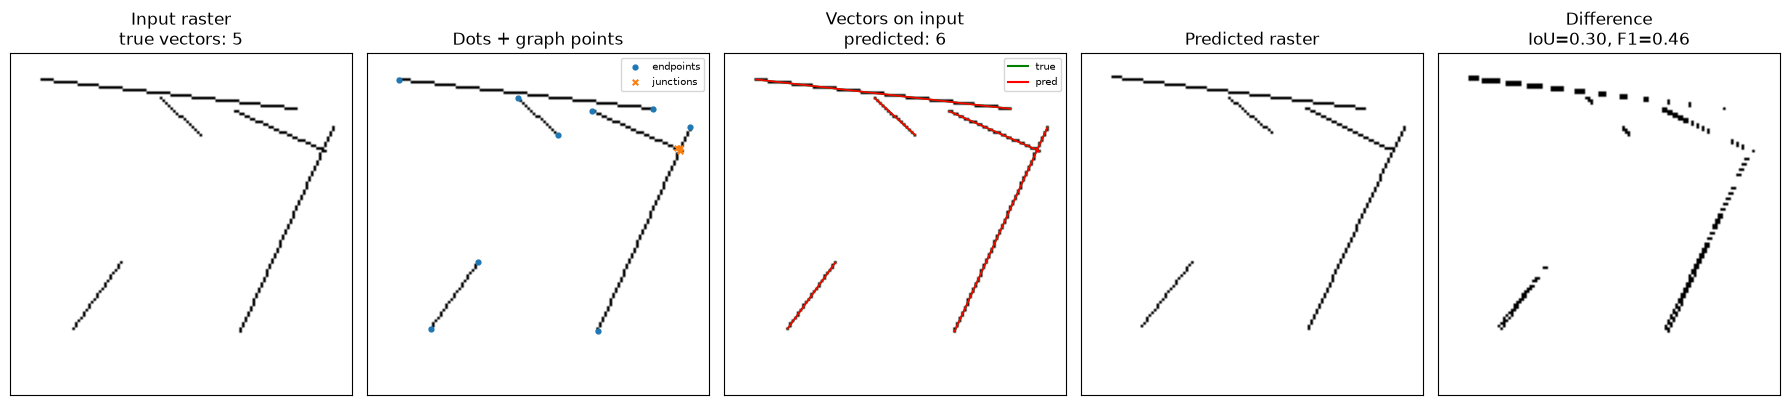

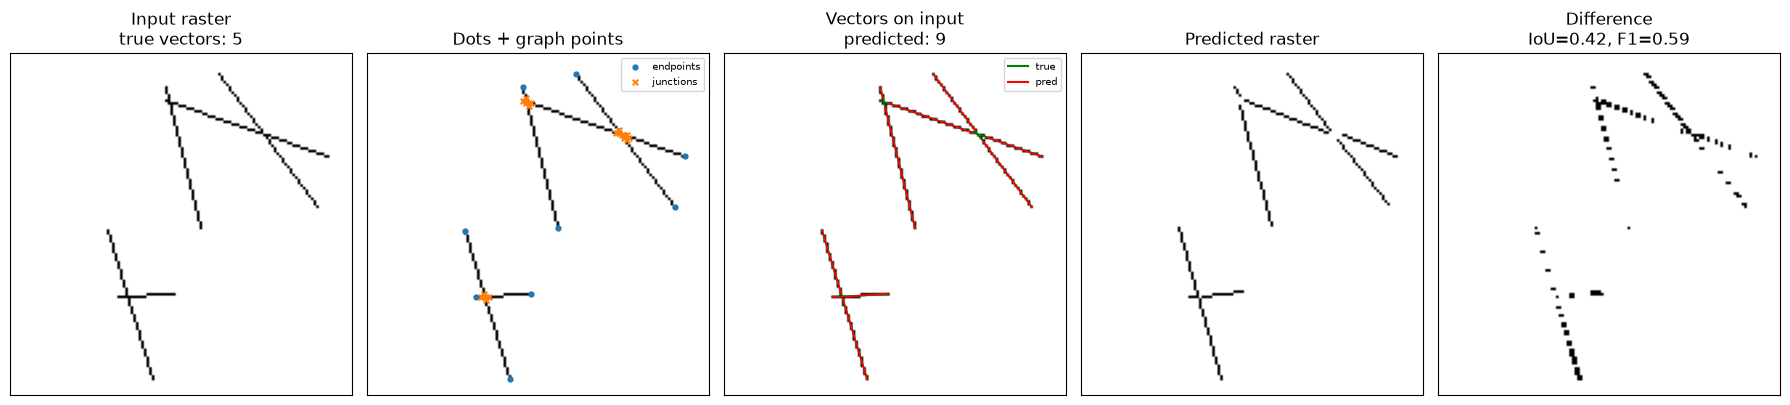

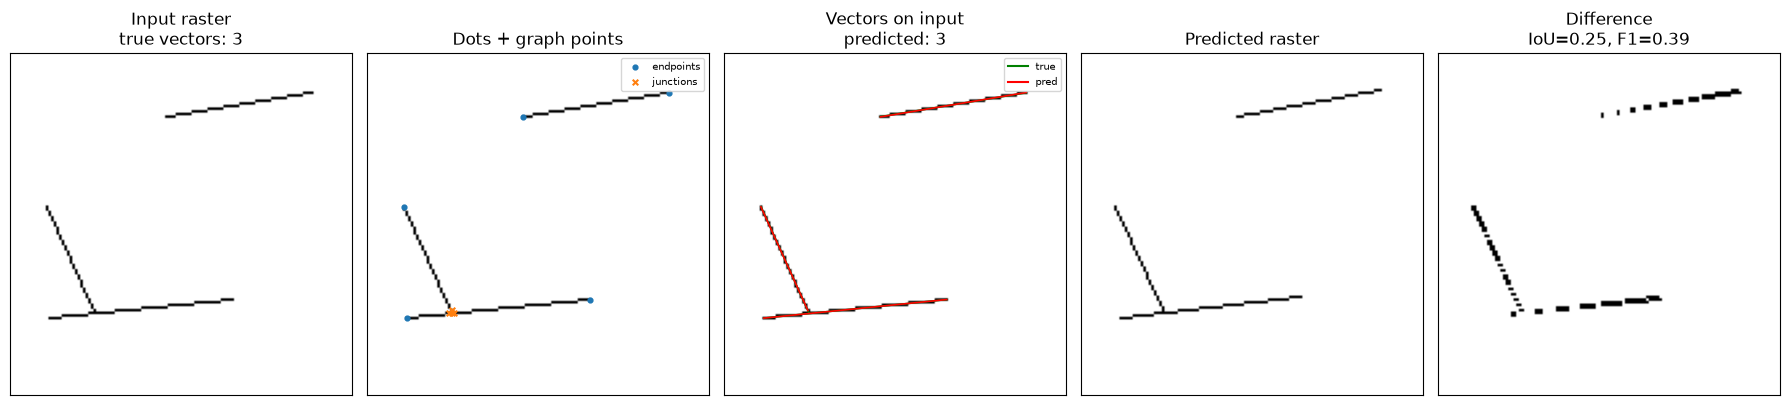

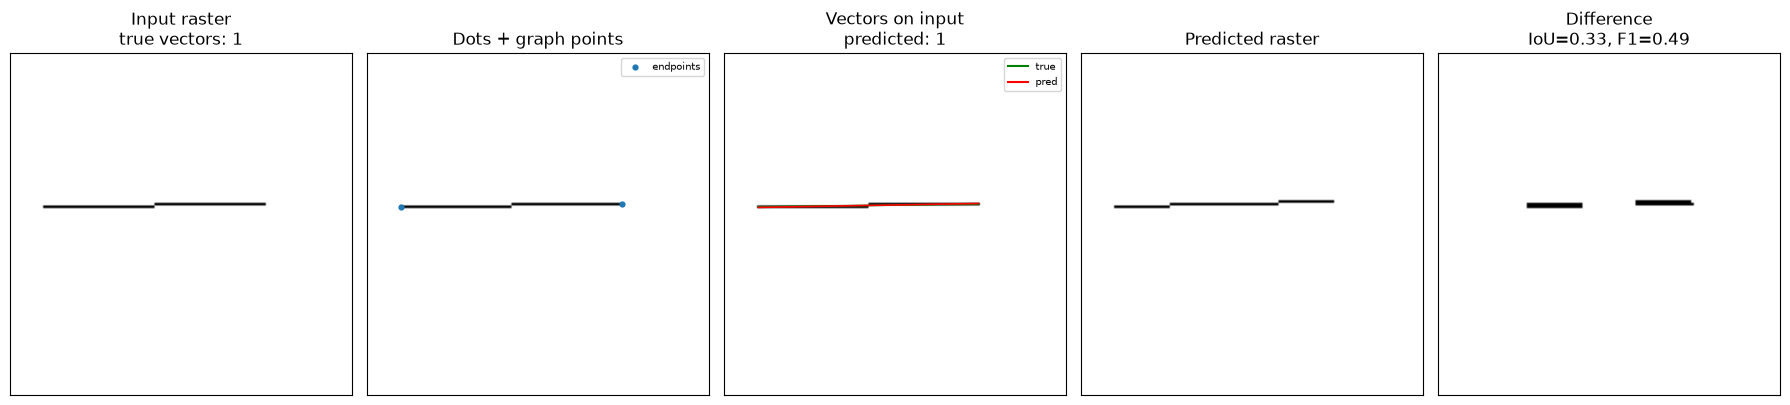

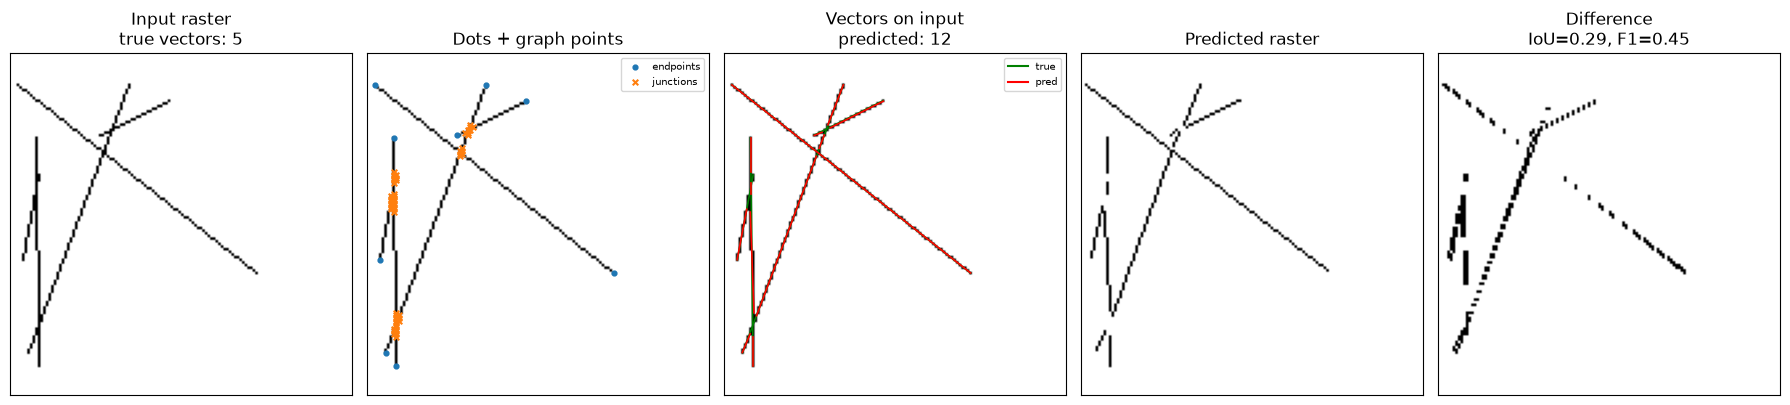

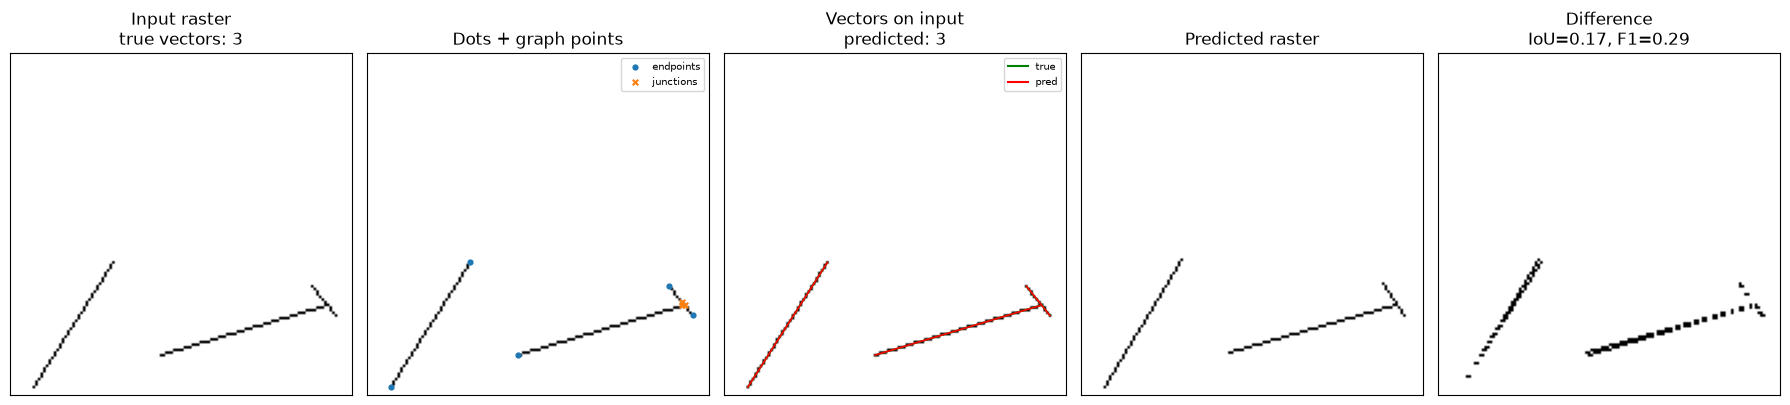

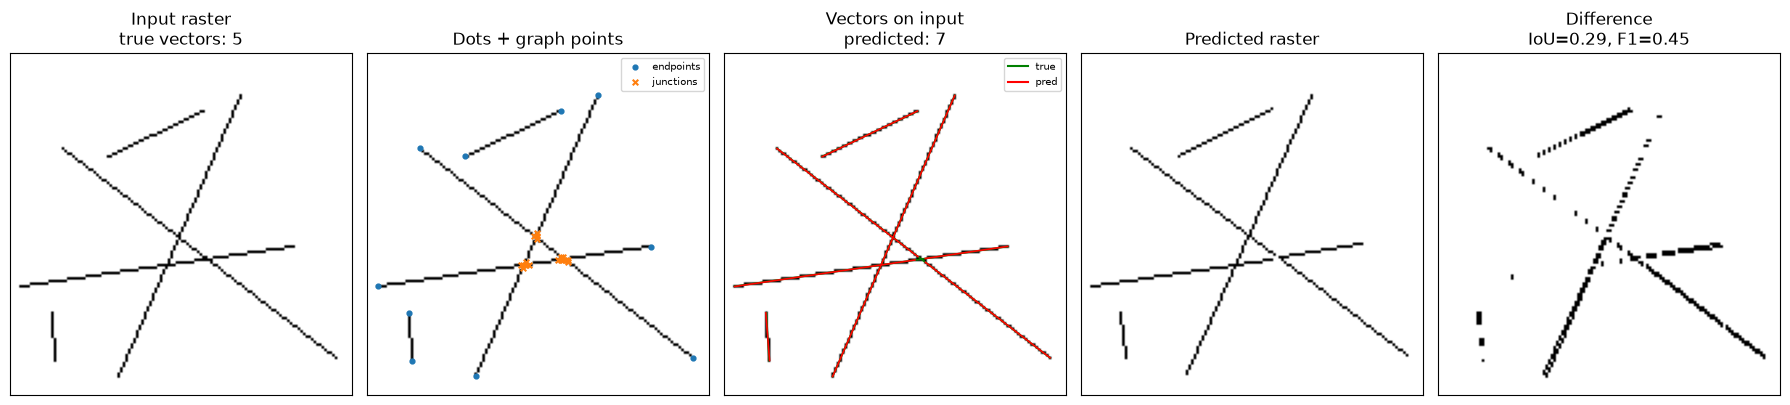

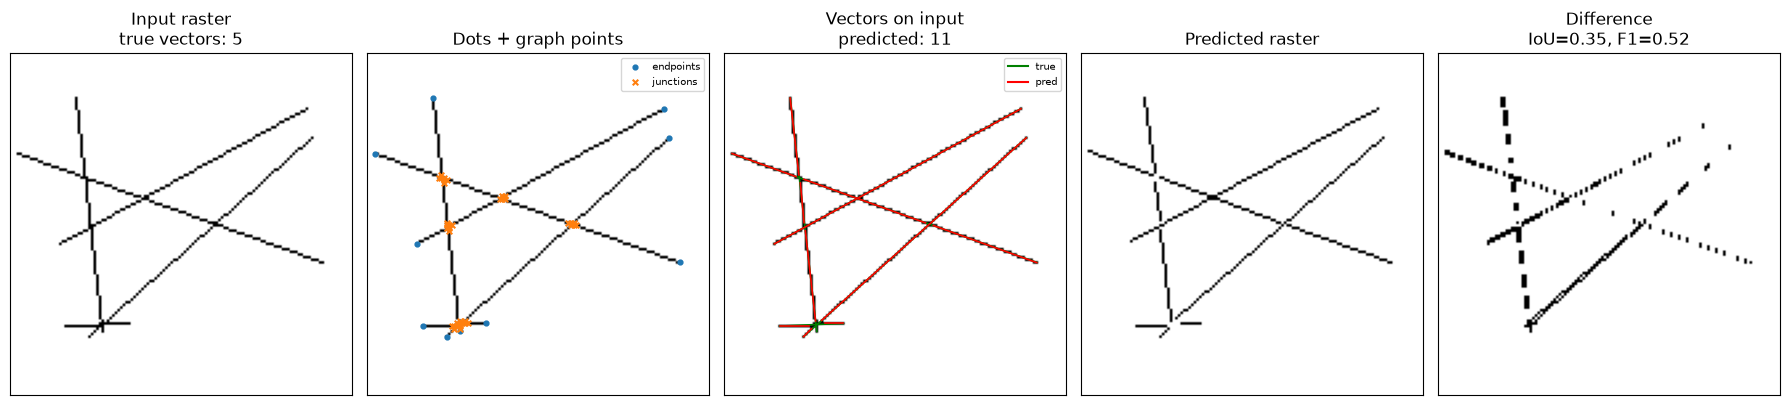

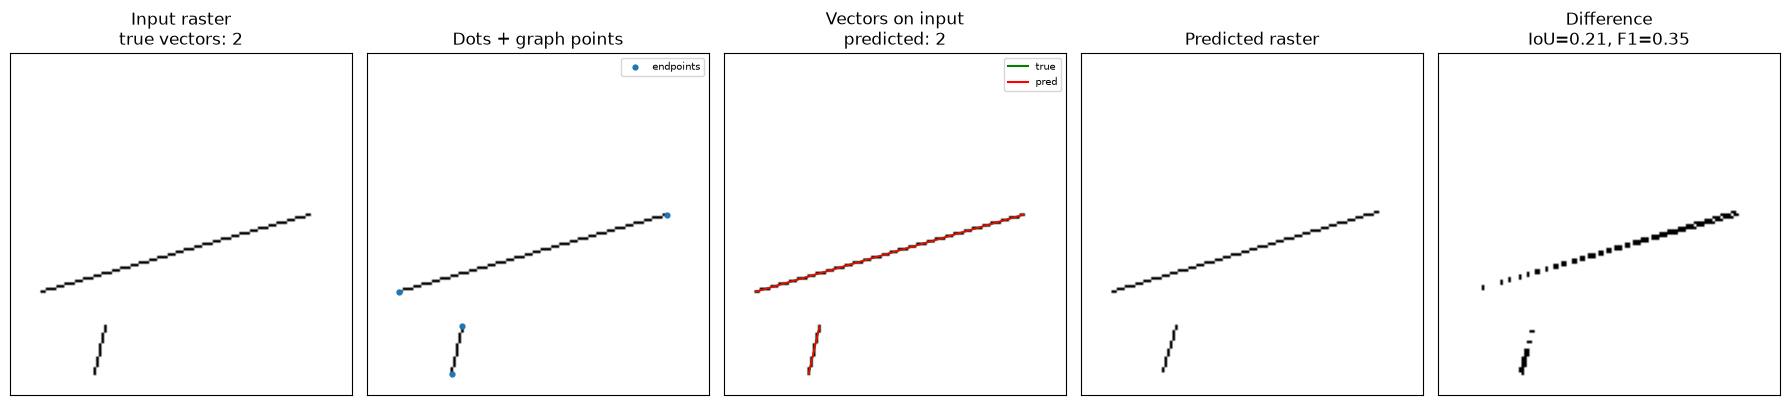

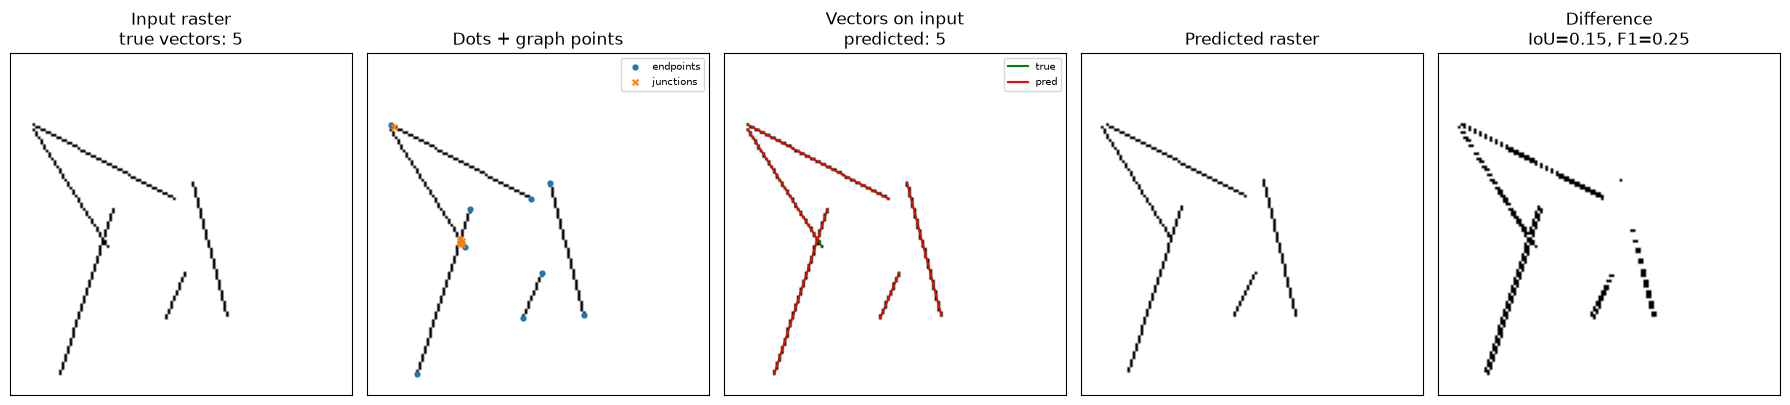

In [14]:
# Show 10 random examples
random_indices = random.sample(range(N_SAMPLES), 10)

for idx in random_indices:
    print("=" * 80)
    print(f"Sample {idx}")
    show_result(idx)


## 11. Dataset-level evaluation

This gives a simple quantitative baseline over all generated samples.


In [15]:
all_metrics = []
vector_count_rows = []

for i in range(N_SAMPLES):
    result = vectorise_raster_adaptive(raster_images[i])
    pred_raster = raster_from_predicted_lines(result['merged_lines'])
    m = raster_metrics(raster_images[i], pred_raster)
    all_metrics.append(m)
    vector_count_rows.append((len(true_vectors[i]), len(result['merged_lines'])))

mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in ['precision', 'recall', 'f1', 'iou']}
print('Mean raster metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.3f}')

true_counts = np.array([r[0] for r in vector_count_rows])
pred_counts = np.array([r[1] for r in vector_count_rows])
print('\nVector count accuracy:', float(np.mean(true_counts == pred_counts)))
print('Mean true vector count:', true_counts.mean())
print('Mean predicted vector count:', pred_counts.mean())


Mean raster metrics:
precision: 0.461
recall: 0.450
f1: 0.455
iou: 0.303

Vector count accuracy: 0.565
Mean true vector count: 3.255
Mean predicted vector count: 4.395


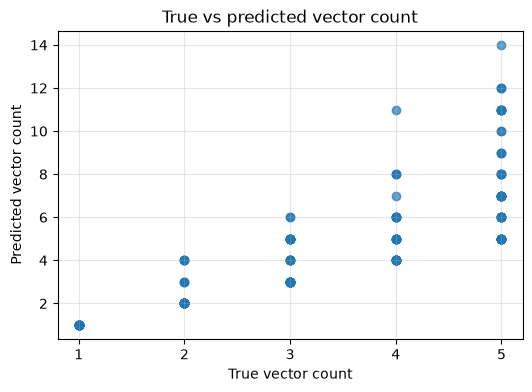

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(true_counts, pred_counts, alpha=0.7)
plt.xlabel('True vector count')
plt.ylabel('Predicted vector count')
plt.title('True vs predicted vector count')
plt.xticks(range(1, MAX_LINES + 1))
plt.grid(True, alpha=0.3)
plt.show()


## 12. Notes for extension

Useful next steps:

- Add controlled noise and test robustness.
- Add curves and recursively split branches where line fit error is high.
- Compare this method against Hough Transform, contour tracing, skeletonisation, and a neural network model.
- Add endpoint distance metrics, not just raster IoU.
- Export predicted vectors as JSON, SVG, or DXF-like line data.
